In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import numpy as np

output_npz_path = '../data/results_multiGPU/dem_all_20170906_12_03_24.npz'
original_npz_path = "../data/np32/20170906_12_00_12.npz"

In [2]:
# Load outputs and reshape to (H, W, T) if needed
with np.load(output_npz_path) as data:
    dem = data['dem_all']

print(f"Loaded DEM raw shape: {dem.shape}")  

Loaded DEM raw shape: (16777216, 10)


In [3]:

# If stored as (N, T) where N = H*W, reshape to (H, W, T)
if dem.ndim == 2:
    N, T = dem.shape
    side = int(np.sqrt(N))
    if side * side != N:
        raise ValueError(f"Cannot reshape first dimension {N} into a square image")
    dem = dem.reshape(side, side, T)
    print(f"Reshaped DEM to (H, W, T): {dem.shape}")
elif dem.ndim == 3:
    H, W, T = dem.shape
    print(f"DEM already has (H, W, T): {H}x{W}x{T}")
    T = dem.shape[2]
else:
    raise ValueError(f"Unexpected DEM ndim={dem.ndim}")


print(f"DEM: min={dem.min():.3f}")
print(f"DEM: max={dem.max():.3f}")
print(f"DEM: mean={dem.mean():.3f}")

Reshaped DEM to (H, W, T): (4096, 4096, 10)
DEM: min=-60744169116874741267900434169686913190283468479358446120975656196764731008501153792.000
DEM: max=225193481153529114343695242646282303369504635741562371947464505990141787151412494336.000
DEM: mean=4113800405043148057050201898062142760278861504947603065261785088.000


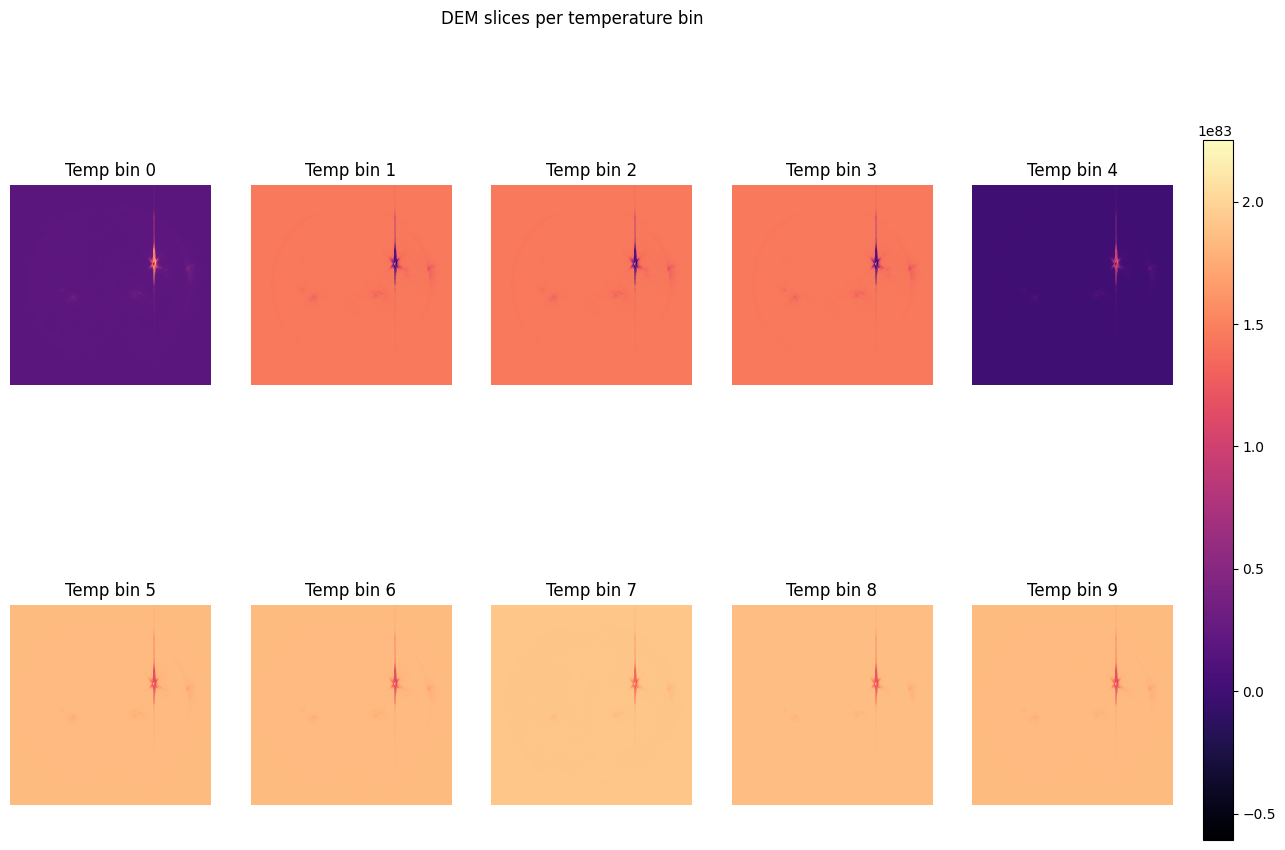

In [7]:
# Convenience vars
H, W, T = dem.shape

# Make subplot for each temperature bin (2x5)
plt.figure(figsize=(15, 10))
for t in range(T):
    plt.subplot(2, 5, t+1)
    plt.imshow(dem[:, :, t], cmap='magma')
    plt.title(f'Temp bin {t}')
    plt.axis('off')

# Add 1 colorbar to plot underneath

cbar_ax = plt.gcf().add_axes([0.92, 0.15, 0.02, 0.7])
norm = plt.Normalize(vmin=dem.min(), vmax=dem.max())
sm = plt.cm.ScalarMappable(cmap='magma', norm=norm)
sm.set_array([])
plt.colorbar(sm, cax=cbar_ax)

plt.suptitle('DEM slices per temperature bin')
plt.show()

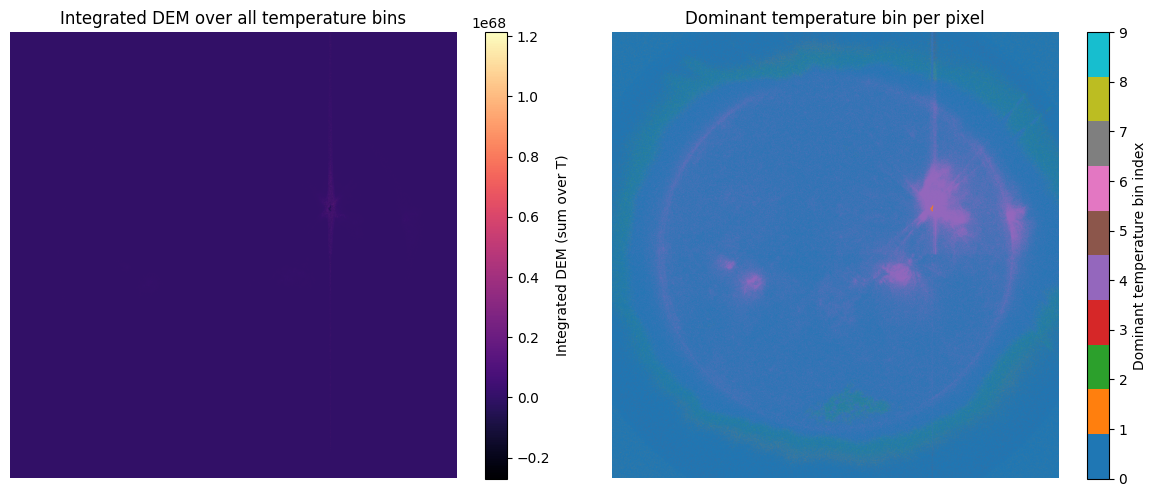

In [6]:
# subplots for summed and max bin
summed = dem.sum(axis=2)
dominant_bin = np.argmax(dem, axis=2)


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(summed, cmap='magma')
plt.colorbar(label='Integrated DEM (sum over T)')
plt.title('Integrated DEM over all temperature bins')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(dominant_bin, cmap='tab10')
plt.colorbar(label='Dominant temperature bin index')
plt.title('Dominant temperature bin per pixel')
plt.axis('off')
plt.tight_layout()
plt.show()